In [1]:
import os
import random
import numpy as np
from osgeo import gdal
from osgeo import gdalconst
from osgeo.gdalconst import *
try:
            from osgeo import ogr
except:
            import ogr
from sklearn.model_selection import RepeatedKFold
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,cross_val_score,cross_validate,GridSearchCV
from sklearn import preprocessing
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,recall_score,f1_score,classification_report,roc_curve,auc
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 读入样本

In [2]:
#  读取数据
def extract_value(shp_filename):
    path1 = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_20\ProcessData\textural.dat'
    path2 = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_20\ProcessData\Radiometic_calibration_After_PCA\Radiometic_calibration_After_PCA.dat'
        
    path = [path1,path2]
    array_value = []
    for paths in path:
        dataset = gdal.Open(paths)    
        bandcount = dataset.RasterCount  
        ##获取放射变换信息
        
        transform = dataset.GetGeoTransform()
        xOrigin = transform[0]
        yOrigin = transform[3]
        pixelWidth = transform[1]
        pixelHeight = transform[5]
        driver = ogr.GetDriverByName('ESRI Shapefile')
        #打开矢量，获取图层
        datasource = driver.Open(shp_filename,0)
        layer = datasource.GetLayer(0)
        
        
        #获取要素及要素地理位置
        xValues = []
        yValues = []
        feature = layer.GetNextFeature()
        while feature:
            geometry = feature.GetGeometryRef()
            x = geometry.GetX()
            y = geometry.GetY()
            xValues.append(x)
            yValues.append(y)  
            feature = layer.GetNextFeature()
        
        value = []
        for i in range(len(xValues)):
            x = xValues[i]
            y = yValues[i]
            xOffset = int((x-xOrigin)/pixelWidth)
            yOffset = int((y-yOrigin)/pixelHeight)
            
            for j in range(bandcount):    
                band = dataset.GetRasterBand(j+1)   # 波段索引从1开始
                data = band.ReadAsArray(xOffset, yOffset,1,1)
                
                value.append(data[0,0])
            
        array =(np.array(value).reshape(-1,1)).reshape(len(xValues),bandcount)
        array_value.append(array)
    array = np.column_stack((array_value[0],array_value[1]))
    return array



In [3]:
water_filename = r'E:\essay_data_fanmeng\Result\LC08_123039_20191020\train_water_sample_point.shp'
water_file = water_filename
water_value = extract_value(water_file )


other_filename = r'E:\essay_data_fanmeng\Result\LC08_123039_20191020\train_other_sample_point.shp'
other_file = other_filename
other_value= extract_value(other_file )
#other_value = np.array(random.sample(list(other_value),380))



In [4]:
value = np.concatenate((water_value,other_value),axis = 0)


In [5]:
value.shape

(794, 6)

In [6]:

# 贴标签打乱数据顺序

water_tag = np.ones((340,))

other_tag = -np.ones((454,))

tag = np.concatenate((water_tag,other_tag),axis = 0)

np.random.seed(11)
np.random.shuffle(value) 
np.random.seed(11)
np.random.shuffle(tag)

# 数据集划分

In [7]:
X_trainval,X_test,y_trainval,y_test = train_test_split(value,tag,random_state=1,test_size = 0.25)


scaler = preprocessing.StandardScaler().fit(X_trainval)
X_trainval = scaler.transform(X_trainval)

X_test = scaler.transform(X_test)

# 预测样本

In [8]:
def predict_class():
    path1 = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\textural.dat'
    path2 = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\Radiometic_calibration_After_PCA\Radiometic_calibration_After_PCA.dat'
        
    path = [path1,path2]
    array_value = []
    for paths in path:
        dataset = gdal.Open(paths)    
        bandcount = dataset.RasterCount  
        cols = dataset.RasterXSize
        rows = dataset.RasterYSize
        geoTransform = dataset.GetGeoTransform()
        proj = dataset.GetProjection()
        for i in range(1,bandcount+1):
            band = dataset.GetRasterBand(i)
            array = band.ReadAsArray(0,0,cols,rows).reshape(-1,1)       
                    
            array_value.append(array)
    array = np.array((array_value[0],array_value[1],array_value[2],array_value[3],array_value[4],array_value[5]))[:,:,0]
    return array.T,cols,rows,geoTransform,proj


In [11]:
x_value,cols,rows,geoTransform,proj  = predict_class()
x_value = scaler.transform(x_value)

## 1 svm

In [13]:
svm = SVC(C = 3, gamma = 0.003,kernel = 'rbf',cache_size= 1000,probability = True)
svm  = svm.fit(X_trainval,y_trainval)

In [40]:




svm_result = svm.predict(x_value).reshape(rows,cols)

# #  输出
driver = gdal.GetDriverByName('GTiff')
outDataset = driver.Create(r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult\svmPredictResult.tif'
                           ,cols,rows,1,gdal.GDT_Float32) 

outDataset.SetGeoTransform(geoTransform)
outDataset.SetProjection(proj)

outBand = outDataset.GetRasterBand(1)
outBand.WriteArray(svm_result)

outBand.FlushCache()
outDataset.FlushCache()

del svm_result


## 2随机森林

In [15]:
rfc = RandomForestClassifier(n_estimators=10
                            ,random_state=90
                            ,max_depth=4
                            ,max_features=2
                            ,min_samples_leaf=1
                            ,min_samples_split=6
                            ,criterion = 'gini'
                        )


rfc.fit(X_trainval,y_trainval)

RandomForestClassifier(max_depth=4, max_features=2, min_samples_split=6,
                       n_estimators=10, random_state=90)

In [41]:

rfc_pred = rfc.predict(x_value).reshape(rows,cols)

#  输出
driver = gdal.GetDriverByName('GTiff')
outDataset = driver.Create(r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult\RandomForestPredictResult.tif'
                           ,cols,rows,1,gdal.GDT_Float32) 

outDataset.SetGeoTransform(geoTransform)
outDataset.SetProjection(proj)

outBand = outDataset.GetRasterBand(1)
outBand.WriteArray(rfc_pred)
#
outBand.FlushCache()
outDataset.FlushCache()

del rfc_pred

## 3决策树

In [17]:
clf  =tree.DecisionTreeClassifier(random_state = 30 ,splitter="random"
                                  ,criterion='entropy'
                                  ,max_depth=7
                                  ,min_samples_leaf=1
                                  ,min_samples_split=8
                                )

clf.fit(X_trainval,y_trainval)

DecisionTreeClassifier(criterion='entropy', max_depth=7, min_samples_split=8,
                       random_state=30, splitter='random')

In [42]:

dt_pred = clf.predict(x_value).reshape(rows,cols)

#  输出
driver = gdal.GetDriverByName('GTiff')
outDataset = driver.Create(r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult\DecisionTreePredictResult.tif'
                           ,cols,rows,1,gdal.GDT_Float32) 

outDataset.SetGeoTransform(geoTransform)
outDataset.SetProjection(proj)

outBand = outDataset.GetRasterBand(1)
outBand.WriteArray(dt_pred)
#
outBand.FlushCache()
outDataset.FlushCache()
del dt_pred

## 4神经网络

In [12]:

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler


MLP = MLPClassifier(solver='lbfgs',  max_iter=600,batch_size=50,activation= 'logistic'
                    ,alpha=1e-5
                    ,hidden_layer_sizes=(8,2)
                    ,random_state=2)  
MLP.fit(X_trainval, y_trainval)


MLPClassifier(activation='logistic', alpha=1e-05, batch_size=50,
              hidden_layer_sizes=(8, 2), max_iter=600, random_state=2,
              solver='lbfgs')

In [13]:

MLP_pred = MLP.predict(x_value).reshape(rows,cols)


In [15]:
MLP_pred.min()

-1.0

In [16]:
MLP_pred = MLP.predict(x_value).reshape(rows,cols)
#  输出
driver = gdal.GetDriverByName('GTiff')
outDataset = driver.Create(r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult\mlpPredictResult.tif'
                           ,cols,rows,1,gdal.GDT_Int16) 

outDataset.SetGeoTransform(geoTransform)
outDataset.SetProjection(proj)

outBand = outDataset.GetRasterBand(1)
outBand.WriteArray(MLP_pred)
#
outBand.FlushCache()
outDataset.FlushCache()

del MLP_pred

## 5xgboost

In [24]:
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn import metrics
#param_grid = {'max_depth':np.arange(1,50,1)}

XGB = XGBClassifier(n_estimators=300
                        ,random_state=91
                        ,max_depth=3
                    ,colsample_btree=5
                    ,subsample=0.58
                    ,gamma= 0.5
                    ,slient = 5
                    #,learning_rate=0.054
                   )
#XGB  = GridSearchCV(XGB,param_grid,cv = 10,scoring='f1')

XGB.fit(X_trainval,y_trainval)



[11:16:14] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.1.0\src\learner.cc:480: 
Parameters: { colsample_btree, slient } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.




XGBClassifier(base_score=0.5, booster='gbtree', colsample_btree=5,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              gamma=0.5, gpu_id=-1, importance_type='gain',
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=3, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=300, n_jobs=0,
              num_parallel_tree=1, random_state=91, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=1, slient=5, subsample=0.58, tree_method='exact',
              validate_parameters=1, verbosity=None)

In [50]:

XGB_pred = XGB.predict(x_value).reshape(rows,cols)

#  输出
driver = gdal.GetDriverByName('GTiff')
outDataset = driver.Create(r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult\xgboostPredictResult.tif'
                           ,cols,rows,1,gdal.GDT_Float32) 

outDataset.SetGeoTransform(geoTransform)
outDataset.SetProjection(proj)

outBand = outDataset.GetRasterBand(1)
outBand.WriteArray(XGB_pred)
#
outBand.FlushCache()
outDataset.FlushCache()

del XGB_pred

## 6 逻辑回归

In [26]:
from sklearn.linear_model import LogisticRegression 

In [27]:


LR = LogisticRegression (solver= 'newton-cg',penalty='l2',C = 30,max_iter=100,random_state=2)
LR.fit(X_trainval, y_trainval)
          


LogisticRegression(C=30, random_state=2, solver='newton-cg')

In [51]:

LR_pred = LR.predict(x_value).reshape(rows,cols)

#  输出
driver = gdal.GetDriverByName('GTiff')
outDataset = driver.Create(r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult\LogisticRegressionPredictResult.tif'
                           ,cols,rows,1,gdal.GDT_Float32) 

outDataset.SetGeoTransform(geoTransform)
outDataset.SetProjection(proj)

outBand = outDataset.GetRasterBand(1)
outBand.WriteArray(LR_pred)
#
outBand.FlushCache()
outDataset.FlushCache()

del LR_pred

# 阈值法

## 读取mndwi数据

In [241]:
import os


path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_20\ProcessData\ThresholdExtractResult\area2\area2_clip.tif'

#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


array = band.ReadAsArray(0,0,cols,rows)
type(array)

numpy.ndarray

In [242]:
print(array.max(),array.min())

0.80622506 -3.402823e+38


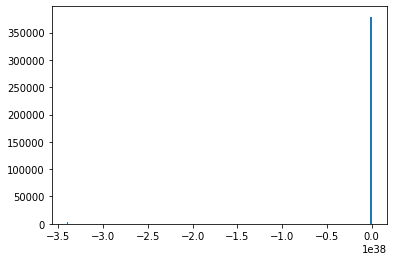

In [243]:
plt.hist(array.ravel(), 256)
plt.show()

In [244]:
# 防治数据出现nan，所以需要去除
import math
for i in range(0,array.shape[0]):
    for j in range(0,array.shape[1]):
       
        if(array[i][j] < -1):
            array[i][j] = 0
        elif(array[i][j] > 1):
            array[i][j] =  1

In [229]:
count = 0
for i in range(0,array.shape[0]):
    for j in range(0,array.shape[1]):
       
        if(array[i][j] < -1):
            count+=1

            
print(count)

2978


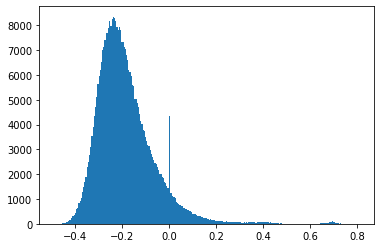

In [245]:
plt.hist(array.ravel(), 256)
plt.show()

## 二值化处理

In [153]:
import cv2

In [139]:
# 固定阈值法

ret1, th1 = cv2.threshold(array, 0, 1,cv2.THRESH_BINARY )

In [110]:
ret1

0.0

In [111]:
for i in range(0,array.shape[0]):
    for j in range(0,array.shape[1]):
    
        if(th1[i][j] > 0):
            th1[i][j] = 1
        else:
            th1[i][j] =  -1

In [112]:
driver = gdal.GetDriverByName('GTiff')

# 这里注意创建的类型和要读入的数据类型的联系，有的数据类型写入有问题。精度高的数据类型写入低的话图像效果不好，尤其对于遥感图像  

outDataset = driver.Create(r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ThresholdExtractResult\area1\CustomThresholdResult.tif'
                           ,cols,rows,1,gdal.GDT_Int16 ) 

# 设置输出栅格的坐标系-地理，投影
outDataset.SetGeoTransform(geoTransform)
outDataset.SetProjection(proj)

outBand = outDataset.GetRasterBand(1)

outBand.WriteArray(th1)

outBand.FlushCache()                                        
outDataset.FlushCache()
del outBand
del outDataset

In [246]:
array = 127.5 * array + 127.5
array = np.array(array,dtype='uint8') 
array.max()

230

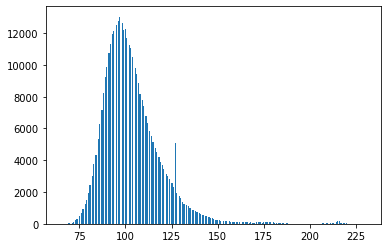

In [247]:




plt.hist(array.ravel(), 256)
plt.show()

In [251]:
#Otsu阈值法
ret2, th2 = cv2.threshold(array, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
ret2

109.0

In [252]:
thresh = (ret2 - 127.5 )/127.5
thresh

-0.1450980392156863

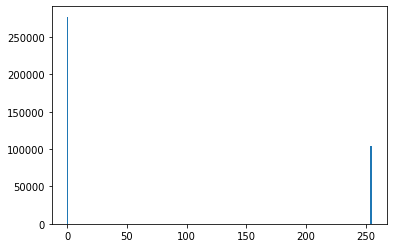

In [253]:

plt.hist(th2.ravel(), 256)
plt.show()

In [237]:
th2 = np.array(th2,dtype='int') 

In [254]:
for i in range(0,array.shape[0]):
    for j in range(0,array.shape[1]):
        if th2[i][j] > 0:
            th2[i][j] = 1
        else:
            th2[i][j]= -1

In [255]:
print(th2.max(),th2.min())

255 1


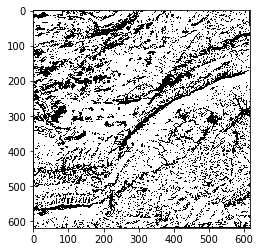

In [256]:
plt.imshow(th2,cmap = 'bone')

In [257]:
driver = gdal.GetDriverByName('GTiff')

# 这里注意创建的类型和要读入的数据类型的联系，有的数据类型写入有问题。精度高的数据类型写入低的话图像效果不好，尤其对于遥感图像  
outDataset = driver.Create(r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ThresholdExtractResult\area2\OustThresholdResult11.tif'
                           ,cols,rows,1,gdal.GDT_Int16) 

# 设置输出栅格的坐标系-地理，投影
outDataset.SetGeoTransform(geoTransform)
outDataset.SetProjection(proj)

outBand = outDataset.GetRasterBand(1)

outBand.WriteArray(th2)

outBand.FlushCache()                                        
outDataset.FlushCache()



In [120]:
# 自适应
th3 = cv2.adaptiveThreshold(array,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,3,0.2) 

In [121]:
th3 = np.array(th3,dtype='int') 

In [122]:
for i in range(0,array.shape[0]):
    for j in range(0,array.shape[1]):
        if(th3[i][j] > 1):
            th3[i][j] = 1
        else:
            th3[i][j] =  -1

In [123]:
th3.max()

1

In [124]:
th3.min()

-1

In [125]:
driver = gdal.GetDriverByName('GTiff')

# 这里注意创建的类型和要读入的数据类型的联系，有的数据类型写入有问题。精度高的数据类型写入低的话图像效果不好，尤其对于遥感图像  
outDataset = driver.Create(r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ThresholdExtractResult\area1\AdaptiveThresholdResult.tif'
                           ,cols,rows,1,gdal.GDT_Int16) 

# 设置输出栅格的坐标系-地理，投影
outDataset.SetGeoTransform(geoTransform)
outDataset.SetProjection(proj)

outBand = outDataset.GetRasterBand(1)

outBand.WriteArray(th3)

outBand.FlushCache()                                        
outDataset.FlushCache()

